# Sigap.ai - Linear SVM Baseline for Sentiment Analysis

Notebook ini disusun untuk proyek capstone IBM SkillsBuild Sigap.ai sebagai baseline yang dapat langsung dijalankan di Google Colab.

Scope notebook ini dibatasi secara tegas pada data yang sudah final:
- proses data collection sudah selesai
- proses cleaning sudah selesai
- proses labeling sudah selesai
- proses balancing sudah selesai
- proses splitting sudah selesai
- proses preprocessing sudah selesai

Eksperimen ini hanya menggunakan:
- feature: `Review_Text_Processed`
- target: `Sentiment_Label`

Fokus utama notebook:
- membangun baseline Linear SVM yang kuat
- membandingkannya dengan Logistic Regression
- menyajikan evaluasi yang siap dipakai untuk laporan akademik dan advisor meeting

## SECTION 1 - Project Overview

### Tujuan eksperimen
Tujuan eksperimen ini adalah membangun baseline klasifikasi sentimen berbasis teks yang kuat, stabil, dan mudah diinterpretasikan untuk dataset review UMKM Indonesia pada proyek Sigap.ai. Hasil eksperimen akan dipakai sebagai benchmark untuk membandingkan model lanjutan berikutnya.

### Mengapa Linear SVM digunakan pada text classification
Linear SVM sangat sering menjadi baseline kuat untuk teks karena:
- efektif pada feature sparse berdimensi tinggi seperti TF-IDF
- memiliki margin maximization yang membantu generalisasi
- sering unggul pada problem klasifikasi teks dibanding model linear lain
- tetap relatif mudah dijelaskan melalui koefisien fitur pada kernel linear

### Perbedaan Logistic Regression dan SVM
Logistic Regression memodelkan probabilitas kelas secara langsung, sedangkan SVM berfokus pada pemisahan margin antar kelas.
Dalam praktik text classification:
- Logistic Regression sering lebih probabilistik dan lebih mudah diubah ke confidence score
- Linear SVM sering memberikan batas keputusan yang lebih tegas
- keduanya cocok sebagai baseline, tetapi SVM sering lebih kuat pada feature TF-IDF

## SECTION 2 - Import Library

Library yang digunakan dibatasi pada stack yang umum dipakai untuk eksperimen machine learning terstruktur:
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib

In [257]:
import os
from pathlib import Path

import re
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, validation_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler


sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11
pd.set_option('display.max_colwidth', 250)
pd.set_option('display.max_columns', 100)

## SECTION 3 - Load Dataset

Notebook ini mencoba menemukan file dataset secara otomatis agar tetap fleksibel saat dijalankan di Google Colab maupun pada workspace lokal.

File yang didukung:
- `df_train_final.csv` atau `train_final.csv`
- `df_validation_final.csv` atau `validation_final.csv`
- `df_test_final.csv` atau `test_final.csv`

In [258]:
PROJECT_ROOT = Path.cwd()

TRAIN_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "train.csv"
VAL_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "validation.csv"
TEST_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "test.csv"

print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)

print("\nDataset Loaded Successfully")
print("Train      :", df_train.shape)
print("Validation :", df_val.shape)
print("Test       :", df_test.shape)

print("\nColumns:")
print(df_train.columns.tolist())

c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\train.csv
c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\validation.csv
c:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\dataset\processed-dataset\test.csv

Dataset Loaded Successfully
Train      : (14777, 9)
Validation : (3172, 9)
Test       : (3172, 9)

Columns:
['Review_Text', 'Review_Text_Processed', 'Review_Date', 'Rating_Score', 'Business_Category', 'Sentiment_Label', 'Review_Aspect', 'Crisis_Flag', 'Is_Sarcasm']


In [259]:
def load_split(path):
    df = pd.read_csv(path, encoding='utf-8-sig')
    expected_columns = [
        'Review_Text',
        'Review_Text_Processed',
        'Rating_Score',
        'Business_Category',
        'Sentiment_Label',
        'Review_Aspect',
        'Crisis_Flag',
        'Is_Sarcasm',
    ]
    missing = [c for c in expected_columns if c not in df.columns]
    if missing:
        raise ValueError(f'{path.name} missing columns: {missing}')
    return df

train_df = load_split(TRAIN_PATH)
val_df = load_split(VAL_PATH)
test_df = load_split(TEST_PATH)

EXTRA_FEATURES = [
    "Rating_Score",
    "Business_Category",
    "Review_Aspect",
    "Crisis_Flag",
    "Is_Sarcasm"
]

for split_name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f'\n{split_name} shape: {df.shape}')
    print('Label distribution:')
    display(df['Sentiment_Label'].value_counts().to_frame('count'))
    print('Sample data:')
    display(df[['Review_Text_Processed', 'Sentiment_Label']].head(5))


Train shape: (14777, 9)
Label distribution:


,count
Sentiment_Label,
Negative,4932
Netral,4925
Positive,4920


Sample data:


,Review_Text_Processed,Sentiment_Label
0,if you re looking out for the perfect punjabi north indian food hit this right now they have really amazing chicken lollipops and dahi kababs ve ordered quite number of times from this however not visited the restoran yet also try out on their ka...,Positive
1,nasi kebuli cenderung minyak nasi putih kasih bumbu aduk,Netral
2,tidak mahal tidak,Negative
3,kardus rusak kirim jeda hari jual ngasih informasi kirim sopan nope bagus,Negative
4,giur liat review google nunggu tempat penuh banget makan rebut duduk klo tidak sabar ning sen gfood grbfood recommended banget sate pedas banget enaaak banget bener pedes tidak pedes doang gt asin asin kalo asin pedes asin harga murah cuman 15rb ...,Positive



Validation shape: (3172, 9)
Label distribution:


...

,Review_Text_Processed,Sentiment_Label
0,packing rapi,Positive
1,pasti alat makan,Netral
2,tidak sesuai dharapkan harap merek maspion nyata merek mikado label tempel maspion,Negative
3,bagus layan oke makan oke,Positive
4,the bar ambiance is good we ordered chilli broccoli and that had mix of broccoli and cauliflower broccoli was it is at the outer area so there was problem for booking cab also at pm while returning,Negative



Test shape: (3172, 9)
Label distribution:


,count
Sentiment_Label,
Negative,1059
Netral,1057
Positive,1056


Sample data:


,Review_Text_Processed,Sentiment_Label
0,udah sihh,Positive
1,paneer was not good,Negative
2,ordered cappuccino and got black coffee read orders correctly first,Negative
3,sesuai segel hologram,Positive
4,the best for chinese lover the food is very authentic and the layan is bit lambat but you can comfortably eat staf is very nice always ask for recommendations from the staf and their choices are simple perfect and that makes foodie try the best t...,Positive


Feature Engineering

In [260]:
train_rating = train_df[['Rating_Score']]
val_rating = val_df[['Rating_Score']]
test_rating = test_df[['Rating_Score']]

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

train_category = ohe.fit_transform(
    train_df[['Business_Category']]
)

val_category = ohe.transform(
    val_df[['Business_Category']]
)

test_category = ohe.transform(
    test_df[['Business_Category']]
)

## SECTION 4 - Label Encoding

Pada tahap ini label distandarkan menjadi `Positive`, `Neutral`, `Negative`, kemudian diencode agar kompatibel dengan model klasifikasi.
Mapping label disimpan agar interpretasi hasil tetap transparan.

In [261]:
def standardize_label(label):
    label = str(label).strip()
    if label.lower() == 'netral':
        return 'Neutral'
    return label

for df in [train_df, val_df, test_df]:
    df['Sentiment_Label'] = df['Sentiment_Label'].apply(standardize_label)

label_order = ['Negative', 'Neutral', 'Positive']
label_encoder = LabelEncoder()
label_encoder.fit(label_order)

label_mapping = {label: int(label_encoder.transform([label])[0]) for label in label_encoder.classes_}
inverse_label_mapping = {v: k for k, v in label_mapping.items()}

display(pd.DataFrame({'label': list(label_mapping.keys()), 'encoded_value': list(label_mapping.values())}))

train_y = label_encoder.transform(train_df['Sentiment_Label'])
val_y = label_encoder.transform(val_df['Sentiment_Label'])
test_y = label_encoder.transform(test_df['Sentiment_Label'])

,label,encoded_value
0,Negative,0
1,Neutral,1
2,Positive,2


In [262]:
def count_sentiment(text):

    words = text.split()

    pos = sum(
        w in positive_words
        for w in words
    )

    neg = sum(
        w in negative_words
        for w in words
    )

    return pos, neg

In [263]:


def negation(text):

    text = re.sub(
        r"tidak\s+(\w+)",
        r"tidak_\1",
        text
    )

    text = re.sub(
        r"not\s+(\w+)",
        r"not_\1",
        text
    )

    return text

In [264]:
for df in [train_df,val_df,test_df]:
    df["Review_Text_Processed"] = (
        df["Review_Text_Processed"]
        .apply(negation)
    )

## SECTION 5 - TF-IDF Feature Engineering

Eksperimen TF-IDF dilakukan untuk membandingkan representasi teks yang berbeda sebelum model final dibangun.

Konfigurasi yang diuji:
- Unigram
- Bigram
- `max_features = 5000`
- `max_features = 10000`
- `max_features = 20000`

In [265]:
for df in [train_df, val_df, test_df]:
    df["review_len"] = (
        df["Review_Text_Processed"]
        .str.split()
        .str.len()
    )


scaler = MinMaxScaler()

train_df["review_len"] = scaler.fit_transform(
    train_df[["review_len"]]
)

val_df["review_len"] = scaler.transform(
    val_df[["review_len"]]
)

test_df["review_len"] = scaler.transform(
    test_df[["review_len"]]
)

In [266]:
X_train = train_df['Review_Text_Processed'].fillna('').astype(str)
X_val = val_df['Review_Text_Processed'].fillna('').astype(str)
X_test = test_df['Review_Text_Processed'].fillna('').astype(str)

word_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    sublinear_tf=True,
    norm="l2",
    use_idf=True,
    smooth_idf=True,
    ngram_range=(1,3),
    max_features=50000,
    min_df=2,
    max_df=0.95
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    lowercase=True,
    sublinear_tf=True,
    norm="l2",
    use_idf=True,
    smooth_idf=True,
    ngram_range=(3,5),
    max_features=20000,
    min_df=2
)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char = char_tfidf.transform(X_val)
X_test_char = char_tfidf.transform(X_test)

X_train_word = word_tfidf.fit_transform(X_train)
X_val_word = word_tfidf.transform(X_val)
X_test_word = word_tfidf.transform(X_test)

def evaluate_pipeline(pipeline, x_train, y_train, x_eval, y_eval):
    pipeline.fit(x_train, y_train)
    pred = pipeline.predict(x_eval)
    return {
        'accuracy': accuracy_score(y_eval, pred),
        'precision_macro': precision_score(y_eval, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_eval, pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_eval, pred, average='macro', zero_division=0),
        'pred': pred,
        'pipeline': pipeline,
    }

In [267]:
categorical_features = [
    "Business_Category",
    "Review_Aspect"
]

ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

train_cat = ohe.fit_transform(
    train_df[categorical_features]
)

val_cat = ohe.transform(
    val_df[categorical_features]
)

test_cat = ohe.transform(
    test_df[categorical_features]
)

In [268]:

for df in [train_df, val_df, test_df]:

    df["Crisis_Flag"] = (
        df["Crisis_Flag"]
        .map({
            "Yes": 1,
            "No": 0
        })
        .fillna(0)
        .astype("int32")
    )

    df["Is_Sarcasm"] = (
        df["Is_Sarcasm"]
        .map({
            "Yes": 1,
            "No": 0
        })
        .fillna(0)
        .astype("int32")
    )

numeric_features = [
    "Crisis_Flag",
    "Is_Sarcasm",
    "review_len"
]

train_num = csr_matrix(
    train_df[numeric_features]
    .astype("float32")
    .values
)

val_num = csr_matrix(
    val_df[numeric_features]
    .astype("float32")
    .values
)

test_num = csr_matrix(
    test_df[numeric_features]
    .astype("float32")
    .values
)

print("Numeric features ready")
print(train_num.shape)
print(val_num.shape)
print(test_num.shape)

Numeric features ready
(14777, 3)
(3172, 3)
(3172, 3)


In [269]:
X_train_final = hstack([
    X_train_word,
    X_train_char,
    train_cat,
    train_num
])

X_val_final = hstack([
    X_val_word,
    X_val_char,
    val_cat,
    val_num
])

X_test_final = hstack([
    X_test_word,
    X_test_char,
    test_cat,
    test_num
])

In [270]:
print("Train Shape :", X_train_final.shape)
print("Val Shape   :", X_val_final.shape)
print("Test Shape  :", X_test_final.shape)

Train Shape : (14777, 66660)
Val Shape   : (3172, 66660)
Test Shape  : (3172, 66660)


In [271]:
selector = SelectKBest(
    score_func=chi2,
    k=30000
)

X_train_selected = selector.fit_transform(
    X_train_final,
    train_y
)

X_val_selected = selector.transform(
    X_val_final
)

X_test_selected = selector.transform(
    X_test_final
)

## SECTION 6 - Baseline Linear SVM

Baseline model dibangun menggunakan konfigurasi TF-IDF terbaik dari Section 5 dan `LinearSVC()` default.
Evaluasi dilakukan pada validation set untuk mendapatkan baseline yang kredibel sebelum tuning.

In [272]:
baseline_svm = LinearSVC(
    random_state=42
)

baseline_svm.fit(
    X_train_final,
    train_y
)

val_pred_baseline = baseline_svm.predict(
    X_val_final
)

In [273]:
final_classifier = LinearSVC(
    C=2,
    loss="squared_hinge",
    max_iter=10000,
    random_state=42
)

final_classifier.fit(
    X_train_final,
    train_y
)

LinearSVC(C=2, max_iter=10000, random_state=42)

## SECTION 8 - Final Model Training

Final model dibangun menggunakan parameter terbaik dari GridSearchCV. Model kemudian dilatih ulang pada training set agar seluruh data latih berkontribusi pada parameter final.

In [274]:
param_grid = {
    "C": [0.1, 0.5, 1, 2, 5, 10, 20, 50]
}

grid_search = GridSearchCV(
    estimator=LinearSVC(
        class_weight="balanced",
        loss="squared_hinge",
        max_iter=20000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(
    X_train_final,
    train_y
)

print("Best Params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

best_model = grid_search.best_estimator_

val_pred = best_model.predict(X_val_final)
test_pred = best_model.predict(X_test_final)

Best Params: {'C': 0.1}
Best CV F1: 0.7741311892814229


## SECTION 9 - Evaluation

Evaluasi dilakukan pada validation set dan test set dengan metrik berikut:
- Accuracy
- Precision
- Recall
- F1 Score

Selain metrik agregat, notebook juga menampilkan classification report lengkap untuk masing-masing split.

In [275]:
def evaluate_model(model, x, y, split_name):
    pred = model.predict(x)
    metrics = {
        'split': split_name,
        'accuracy': accuracy_score(y, pred),
        'precision_macro': precision_score(y, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y, pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y, pred, average='macro', zero_division=0),
    }
    report_dict = classification_report(
        y,
        pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={'index': 'label'})
    return metrics, pred, report_df


val_metrics, val_pred, val_report_df = evaluate_model(
    best_model,
    X_val_final,
    val_y,
    'validation'
)

test_metrics, test_pred, test_report_df = evaluate_model(
    best_model,
    X_test_final,
    test_y,
    'test'
)
metrics_df = pd.DataFrame([val_metrics, test_metrics])
display(metrics_df)
display(val_report_df)
display(test_report_df)

print('Validation Classification Report')
print(classification_report(val_y, val_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

print('Test Classification Report')
print(classification_report(test_y, test_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.773014,0.776767,0.773001,0.774043
1,test,0.775851,0.779867,0.775873,0.776829


,label,precision,recall,f1-score,support
0,Negative,0.831795,0.766541,0.797836,1058.000000
1,Neutral,0.694323,0.752841,0.722399,1056.000000
2,Positive,0.804183,0.799622,0.801896,1058.000000
3,accuracy,0.773014,0.773014,0.773014,0.773014
4,macro avg,0.776767,0.773001,0.774043,3172.000000
5,weighted avg,0.776819,0.773014,0.774076,3172.000000


,label,precision,recall,f1-score,support
0,Negative,0.845188,0.762984,0.801985,1059.000000
1,Neutral,0.695154,0.746452,0.719891,1057.000000
2,Positive,0.799260,0.818182,0.808610,1056.000000
3,accuracy,0.775851,0.775851,0.775851,0.775851
4,macro avg,0.779867,0.775873,0.776829,3172.000000
5,weighted avg,0.779903,0.775851,0.776834,3172.000000


Validation Classification Report
              precision    recall  f1-score   support

    Negative     0.8318    0.7665    0.7978      1058
     Neutral     0.6943    0.7528    0.7224      1056
    Positive     0.8042    0.7996    0.8019      1058

    accuracy                         0.7730      3172
   macro avg     0.7768    0.7730    0.7740      3172
weighted avg     0.7768    0.7730    0.7741      3172

Test Classification Report
              precision    recall  f1-score   support

    Negative     0.8452    0.7630    0.8020      1059
     Neutral     0.6952    0.7465    0.7199      1057
    Positive     0.7993    0.8182    0.8086      1056

    accuracy                         0.7759      3172
   macro avg     0.7799    0.7759    0.7768      3172
weighted avg     0.7799    0.7759    0.7768      3172



## SECTION 10 - Visualization

Visualisasi dibuat untuk membantu interpretasi performa model secara akademik dan presentatif.

Visualisasi yang disediakan:
1. Confusion Matrix Heatmap
2. Learning Curve
3. Validation Curve
4. Classification Report Heatmap
5. Prediction Distribution
6. Actual vs Prediction Distribution

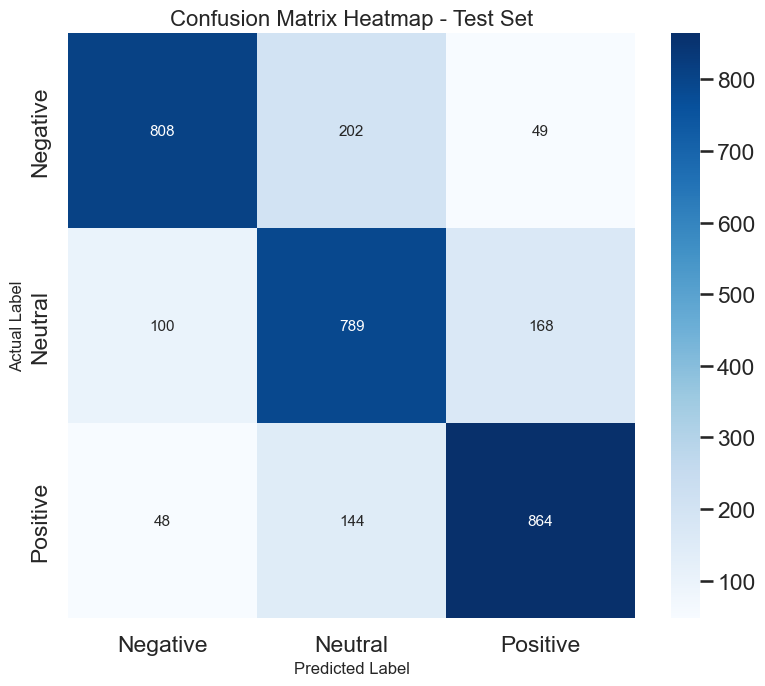

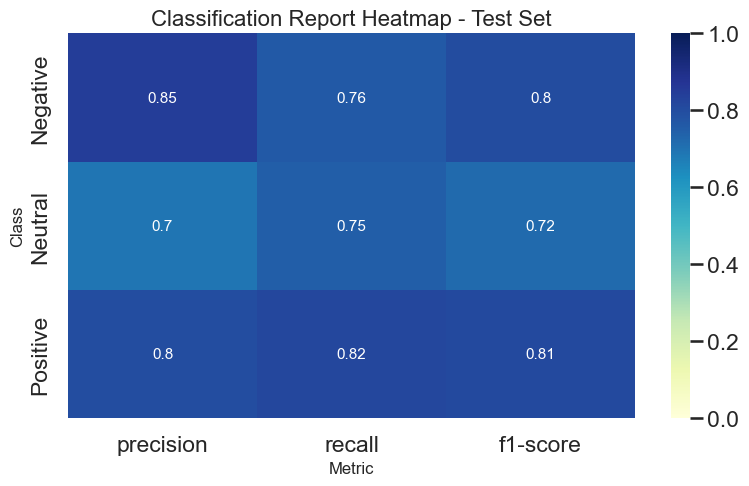

C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_22760\4085616271.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_pred_dist.index, y=val_pred_dist.values, ax=axes[0], palette='viridis')
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_22760\4085616271.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_pred_dist.index, y=test_pred_dist.values, ax=axes[1], palette='viridis')


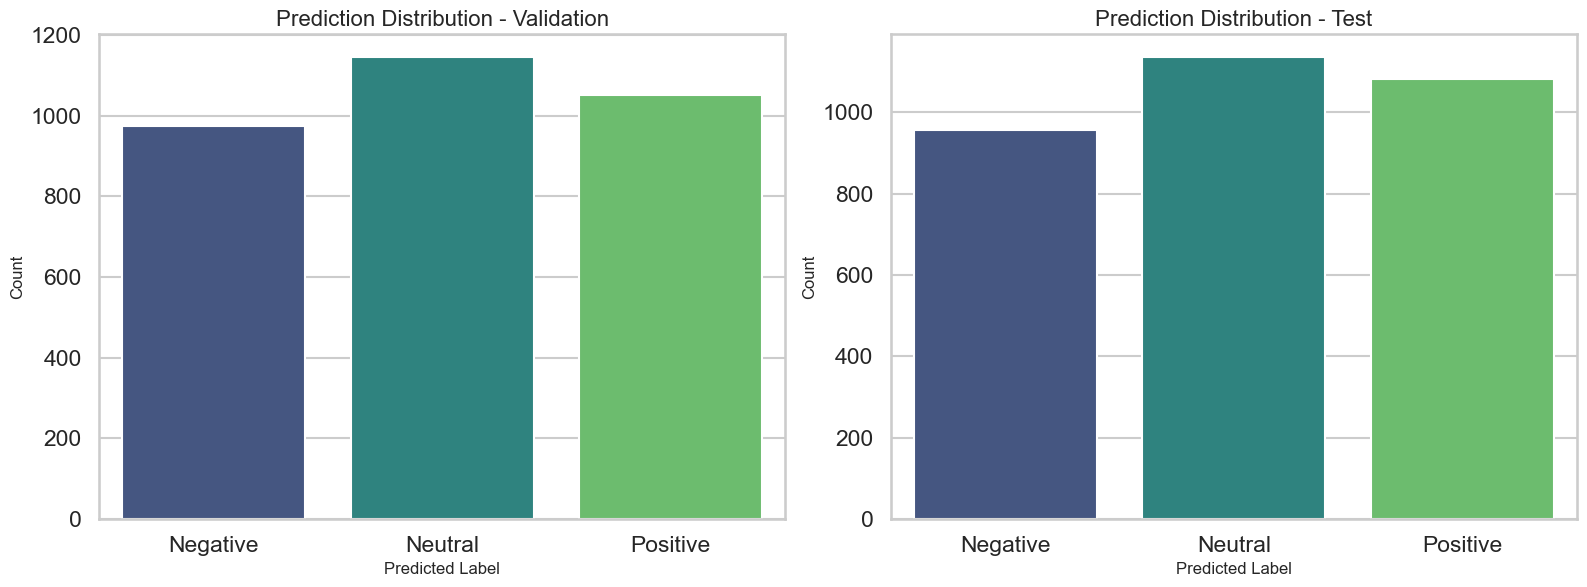

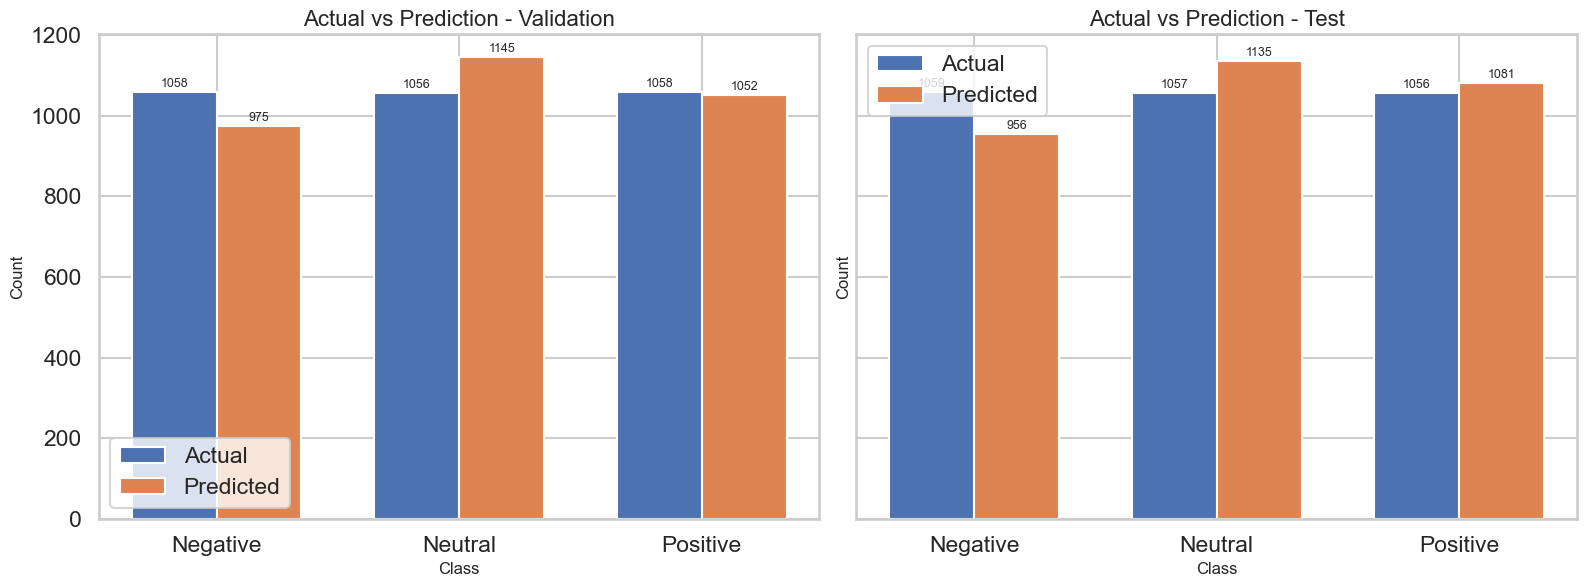

In [276]:
class_names = list(label_encoder.classes_)

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(test_y, test_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix Heatmap - Test Set')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
plt.tight_layout()
plt.show()

# 4. Classification Report Heatmap
report_heatmap_df = pd.DataFrame({
    'precision': classification_report(test_y, test_pred, target_names=label_encoder.classes_, output_dict=True, zero_division=0).keys()
})
test_report_only_classes = pd.DataFrame(classification_report(
    test_y, test_pred, target_names=label_encoder.classes_, output_dict=True, zero_division=0
)).T.loc[label_encoder.classes_, ['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(test_report_only_classes, annot=True, cmap='YlGnBu', vmin=0, vmax=1, ax=ax)
ax.set_title('Classification Report Heatmap - Test Set')
ax.set_xlabel('Metric')
ax.set_ylabel('Class')
plt.tight_layout()
plt.show()

# 5. Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
val_pred_dist = pd.Series(val_pred).map(inverse_label_mapping).value_counts().reindex(class_names).fillna(0)
test_pred_dist = pd.Series(test_pred).map(inverse_label_mapping).value_counts().reindex(class_names).fillna(0)
sns.barplot(x=val_pred_dist.index, y=val_pred_dist.values, ax=axes[0], palette='viridis')
axes[0].set_title('Prediction Distribution - Validation')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Count')
sns.barplot(x=test_pred_dist.index, y=test_pred_dist.values, ax=axes[1], palette='viridis')
axes[1].set_title('Prediction Distribution - Test')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# 6. Actual vs Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
val_actual_dist = pd.Series(val_y).map(inverse_label_mapping).value_counts().reindex(class_names).fillna(0)
test_actual_dist = pd.Series(test_y).map(inverse_label_mapping).value_counts().reindex(class_names).fillna(0)

def grouped_distribution(ax, actual_dist, pred_dist, title):
    x = np.arange(len(class_names))
    width = 0.35
    ax.bar(x - width / 2, actual_dist.values, width=width, label='Actual')
    ax.bar(x + width / 2, pred_dist.values, width=width, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_title(title)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.legend()
    for i, value in enumerate(actual_dist.values):
        ax.text(i - width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)
    for i, value in enumerate(pred_dist.values):
        ax.text(i + width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)

grouped_distribution(axes[0], val_actual_dist, val_pred_dist, 'Actual vs Prediction - Validation')
grouped_distribution(axes[1], test_actual_dist, test_pred_dist, 'Actual vs Prediction - Test')
plt.tight_layout()
plt.show()

## SECTION 11 - Error Analysis

Error analysis difokuskan pada contoh yang salah klasifikasi di test set karena test set adalah representasi paling ketat dari generalisasi model.

Tabel berikut menampilkan 50 contoh salah klasifikasi dengan kolom:
- `Review_Text`
- `Actual_Label`
- `Predicted_Label`

In [277]:
test_predictions_df = pd.DataFrame({
    'Review_Text': test_df['Review_Text'],
    'Review_Text_Processed': test_df['Review_Text_Processed'],
    'Actual_Label': pd.Series(test_y).map(inverse_label_mapping),
    'Predicted_Label': pd.Series(test_pred).map(inverse_label_mapping),
    'Crisis_Flag': test_df['Crisis_Flag'].values,
    'Is_Sarcasm': test_df['Is_Sarcasm'].values,
    'Business_Category': test_df['Business_Category'].values,
    'Review_Aspect': test_df['Review_Aspect'].values,
})

misclassified_df = test_predictions_df[test_predictions_df['Actual_Label'] != test_predictions_df['Predicted_Label']].copy()
error_examples = misclassified_df[['Review_Text', 'Actual_Label', 'Predicted_Label']].head(50)

display(error_examples)

print('Jumlah salah klasifikasi:', len(misclassified_df))
print('Error rate:', round(len(misclassified_df) / len(test_predictions_df) * 100, 2), '%')
print('\nPola kesalahan utama:')
print('- Review pendek atau ringkas lebih sulit dipisahkan antar kelas.')
print('- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.')
print('- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.')
print('- Review dengan konteks domain sangat spesifik dapat diprediksi kurang stabil jika kosakata latih terbatas.')

confusion_pairs = misclassified_df.groupby(['Actual_Label', 'Predicted_Label']).size().sort_values(ascending=False).to_frame('count')
display(confusion_pairs.head(10))

,Review_Text,Actual_Label,Predicted_Label
13,lebih mudah dan cepat memesan lewat app ini.,Neutral,Positive
21,"saya pesan makanan, terus makanannya ada yg kurang. duit nya sudah di kembalikan cuman kurang,yg di kembalikan yg ukuran small, padahal yg kurang medium. pas saya tanya katanya sudah gitu. kurang puas,jadi males pesen makan pake gofood lagi, mend...",Negative,Neutral
28,"nice view, good staf, bersih tempat and nice atmosphere.",Neutral,Positive
34,ambiance were pretty good.,Positive,Neutral
50,sesuai pesanan cuma pengiriman lama,Negative,Positive
53,"Sirloin steak tapi ngunyahnya tuh rasa tenderloin..perfecto bangeett, meleleh dimulut, endulita banget chef..",Neutral,Positive
55,"JMBT, PERKIRAAN WAKTU GAPERNAH SESUAI, UDAH 2 KALI KEJADIAN. SENGAJA NYOBA LAGI SIAPA TAU UDAH UPGRADE, TERNYATA SAMA AJA. CHAT LAPORAN JUGA DIBALAS AMA BOT, MASALAH BELUM KELAR TAPI CUMA ADA OPSI (AKHIRI CHAT DAN KASIH RATING) BAYANGIN AJA GOFOO...",Negative,Neutral
64,"visit this tempat for awesome bakery options. tried pasta and toffee apple doughnut. though pasta is not up to the mark, apple doughnut balanced it out. the ambiance is pretty cool.",Positive,Neutral
68,"gofood,biaya penanganannya seharga satu menu makanan nya",Neutral,Negative
73,"Udah seneng2 dateng kesini 11.30, mau makan, ngerayain ultah, begitu dateng malah seolah2 ditolak mentah2 buat makan disini sama karyawannya karena sholat jumat. Iya gakpapa sholat jumat tapi memangnya gaada siasat apa2 untuk mengatasi ini? Apa g...",Negative,Neutral


Jumlah salah klasifikasi: 711
Error rate: 22.41 %

Pola kesalahan utama:
- Review pendek atau ringkas lebih sulit dipisahkan antar kelas.
- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.
- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.
- Review dengan konteks domain sangat spesifik dapat diprediksi kurang stabil jika kosakata latih terbatas.


,,count
Actual_Label,Predicted_Label,
Negative,Neutral,202
Neutral,Positive,168
Positive,Neutral,144
Neutral,Negative,100
Negative,Positive,49
Positive,Negative,48


## SECTION 12 - Explainable AI

Koefisien Linear SVM digunakan untuk mengekstrak kata-kata yang paling berkontribusi pada masing-masing kelas.

Interpretasi yang digunakan:
- kata dengan bobot tertinggi pada kelas `Positive` dianggap paling mendukung prediksi positif
- kata dengan bobot tertinggi pada kelas `Negative` dianggap paling mendukung prediksi negatif
- kata dengan bobot tertinggi pada kelas `Neutral` dianggap paling mendukung prediksi netral

### Top 20 Features for Positive

,feature,coefficient
0,kirim cepat,0.825988
1,good,0.770083
2,love,0.692459
3,best,0.659995
4,nyaman,0.600984
5,belum coba,0.589510
6,on time,0.573378
7,CHAR_lov,0.557709
8,CHAR_love,0.552588
9,sesuai pesan,0.550630


### Top 20 Features for Neutral

,feature,coefficient
0,fore,1.313214
1,was good,0.604337
2,CHAR_ fore,0.569437
3,tolong,0.547252
4,but,0.541266
5,poin,0.540188
6,CHAR_fore,0.527331
7,Business_Category_F&B,0.527266
8,kecewa,0.519761
9,CHAR_fore,0.511409


### Top 20 Features for Negative

,feature,coefficient
0,Crisis_Flag,1.944925
1,Is_Sarcasm,1.271755
2,worst,0.842141
3,sen makan,0.774681
4,bad,0.732478
5,CHAR_ no,0.686668
6,CHAR_ot_,0.651421
7,CHAR_not_,0.651421
8,CHAR_ not_,0.646686
9,pathetic,0.568136


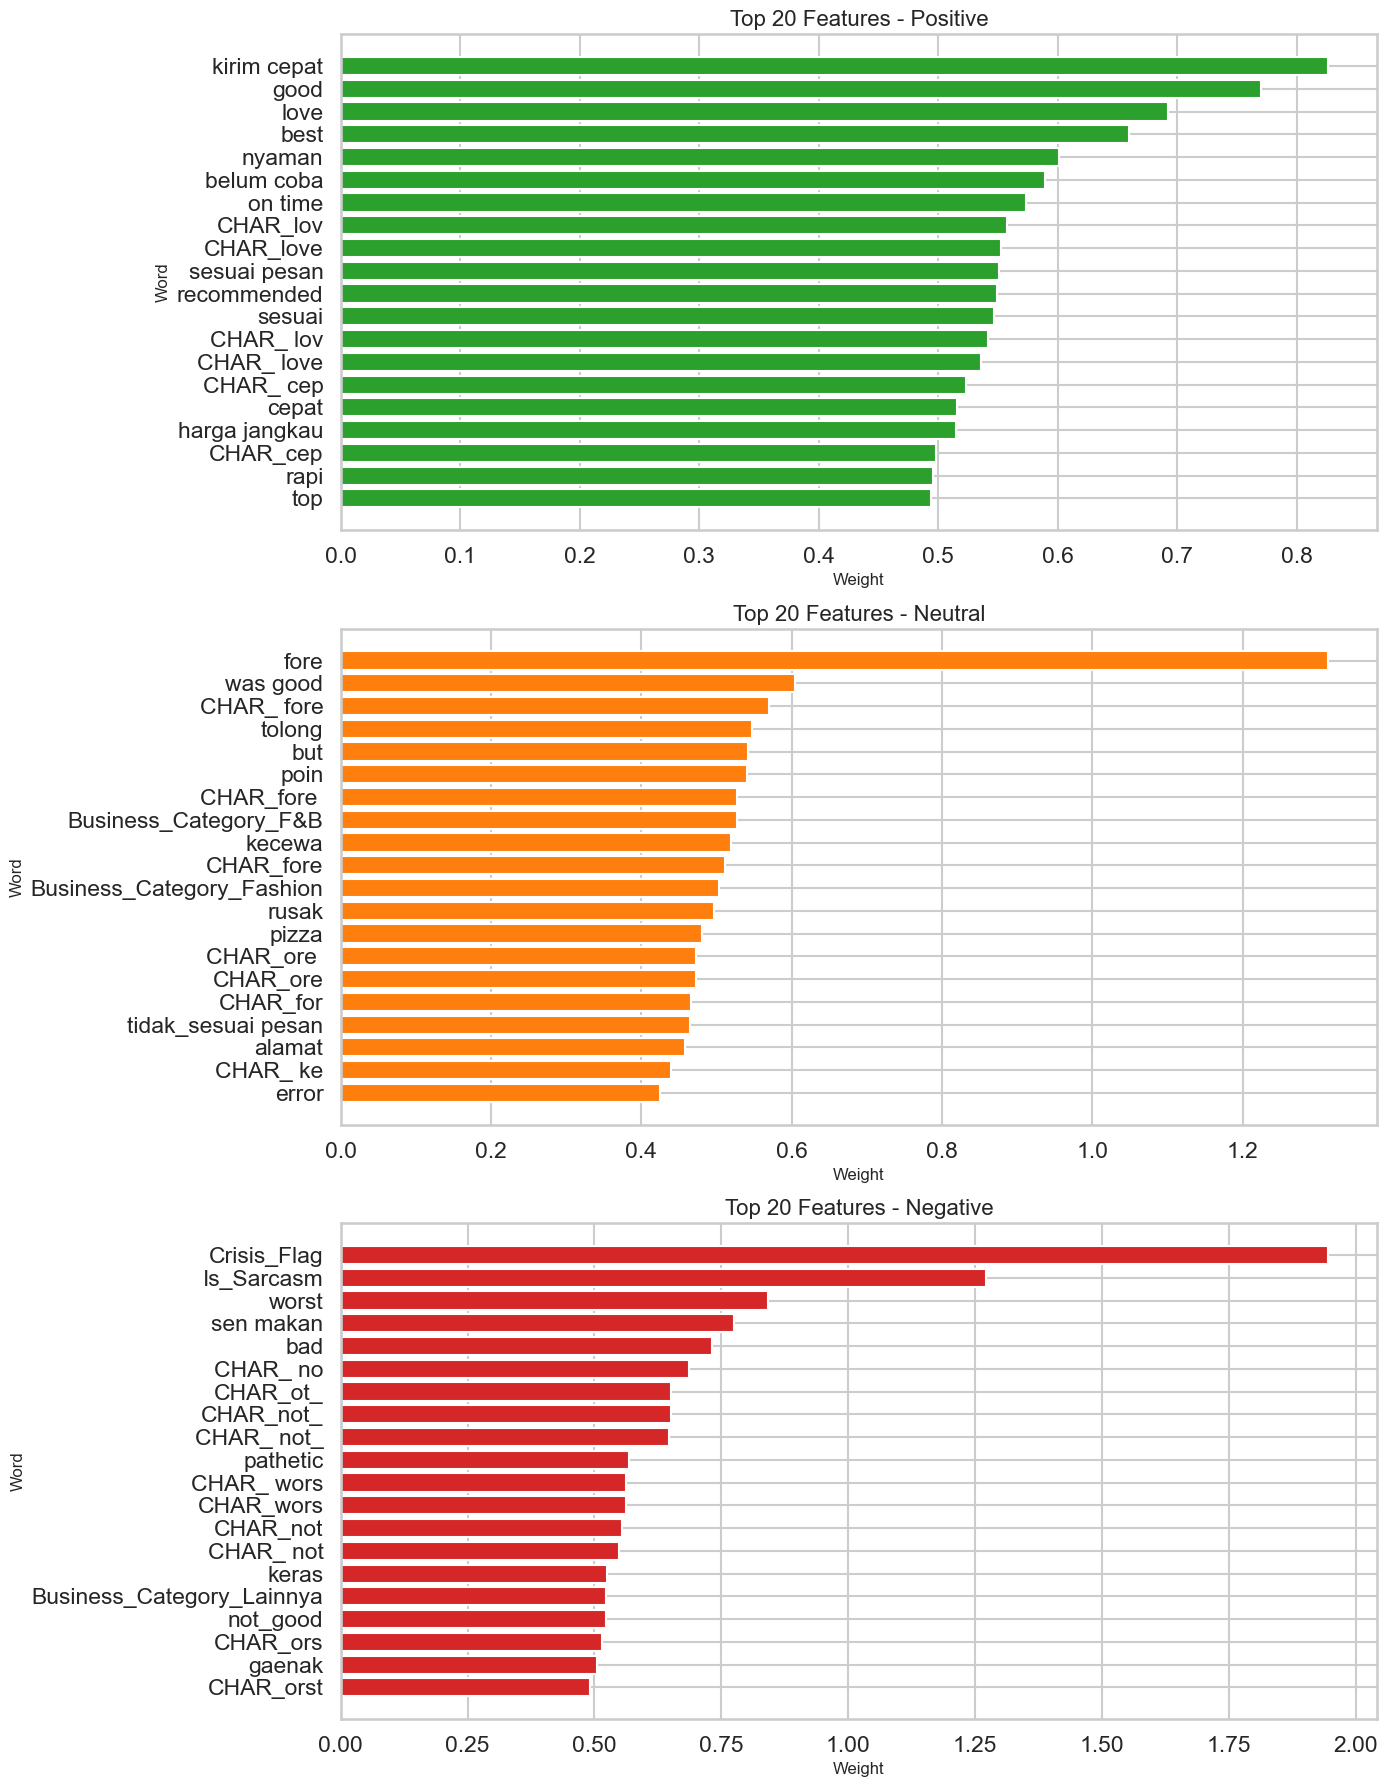

Interpretasi bisnis:
- Fitur positif yang kuat menunjukkan kata yang menandakan kepuasan, kualitas, dan pengalaman baik.
- Fitur negatif yang kuat menunjukkan kata yang mengindikasikan keluhan, gangguan, atau kekecewaan.
- Fitur netral biasanya merepresentasikan kata evaluatif yang tidak ekstrem atau konteks informasional.


In [278]:
word_features = word_tfidf.get_feature_names_out()

char_features = [
    f"CHAR_{x}"
    for x in char_tfidf.get_feature_names_out()
]

feature_names = np.concatenate([
    word_features,
    char_features,
    ohe.get_feature_names_out(categorical_features),
    np.array([
        "Crisis_Flag",
        "Is_Sarcasm"
    ])
])

coef = best_model.coef_
class_names = list(label_encoder.classes_)

def resolve_class_index(class_name):
    encoded_value = label_mapping[class_name]
    return np.where(best_model.classes_ == encoded_value)[0][0]

explainable_tables = {}
for class_name in ['Positive', 'Neutral', 'Negative']:
    class_idx = resolve_class_index(class_name)
    class_coef = coef[class_idx]
    top_idx = np.argsort(class_coef)[-20:][::-1]
    table = pd.DataFrame({
        'feature': feature_names[top_idx],
        'coefficient': class_coef[top_idx],
    })
    explainable_tables[class_name] = table
    display(Markdown(f'### Top 20 Features for {class_name}'))
    display(table)

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
colors = {'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'}
for ax, class_name in zip(axes, ['Positive', 'Neutral', 'Negative']):
    table = explainable_tables[class_name].sort_values('coefficient', ascending=True)
    ax.barh(table['feature'], table['coefficient'], color=colors[class_name])
    ax.set_title(f'Top 20 Features - {class_name}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Word')
plt.tight_layout()
plt.show()

print('Interpretasi bisnis:')
print('- Fitur positif yang kuat menunjukkan kata yang menandakan kepuasan, kualitas, dan pengalaman baik.')
print('- Fitur negatif yang kuat menunjukkan kata yang mengindikasikan keluhan, gangguan, atau kekecewaan.')
print('- Fitur netral biasanya merepresentasikan kata evaluatif yang tidak ekstrem atau konteks informasional.')

## SECTION 13 - Business Analysis

Analisis bisnis digunakan untuk melihat apakah model bekerja konsisten pada subset data tertentu.

Subgroup yang dianalisis:
- `Crisis_Flag`
- `Is_Sarcasm`
- `Review_Aspect`
- `Business_Category`

,Crisis_Flag,count,accuracy,precision_macro,recall_macro,f1_macro
1,1,247,1.000000,1.00000,1.00000,1.000000
0,0,2925,0.756923,0.76189,0.75184,0.755391


,Is_Sarcasm,count,accuracy,precision_macro,recall_macro,f1_macro
1,1,31,1.000000,1.000000,1.00000,1.000000
0,0,3141,0.773639,0.778138,0.77349,0.774733


,Review_Aspect,count,accuracy,precision_macro,recall_macro,f1_macro
0,Bentuk,718,0.817549,0.794679,0.803687,0.798595
2,Lainnya,1296,0.787809,0.794351,0.787470,0.789522
1,Harga,247,0.801619,0.814873,0.754988,0.776828
3,Rasa,911,0.718990,0.713757,0.691778,0.700287


,Business_Category,count,accuracy,precision_macro,recall_macro,f1_macro
4,Ibu & Bayi,11,1.000000,1.000000,1.000000,1.000000
5,Kerajinan & Pesta,16,1.000000,1.000000,1.000000,1.000000
8,Otomotif,10,1.000000,1.000000,1.000000,1.000000
11,Perlengkapan Kantor,12,1.000000,1.000000,1.000000,1.000000
3,Hobi & Hiburan,57,0.859649,0.816667,0.829630,0.816025
9,Perabotan,26,0.807692,0.770202,0.735185,0.738889
1,F&B,2208,0.737319,0.746000,0.715089,0.725717
0,Elektronik,79,0.721519,0.721982,0.722685,0.719146
2,Fashion,57,0.666667,0.707977,0.681917,0.673160
6,Kesehatan & Kecantikan,47,0.808511,0.658951,0.649510,0.650149


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_22760\2207337114.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0, 0], palette='coolwarm')
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_22760\2207337114.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[0, 1], palette='magma')
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_22760\2207337114.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aspect_p

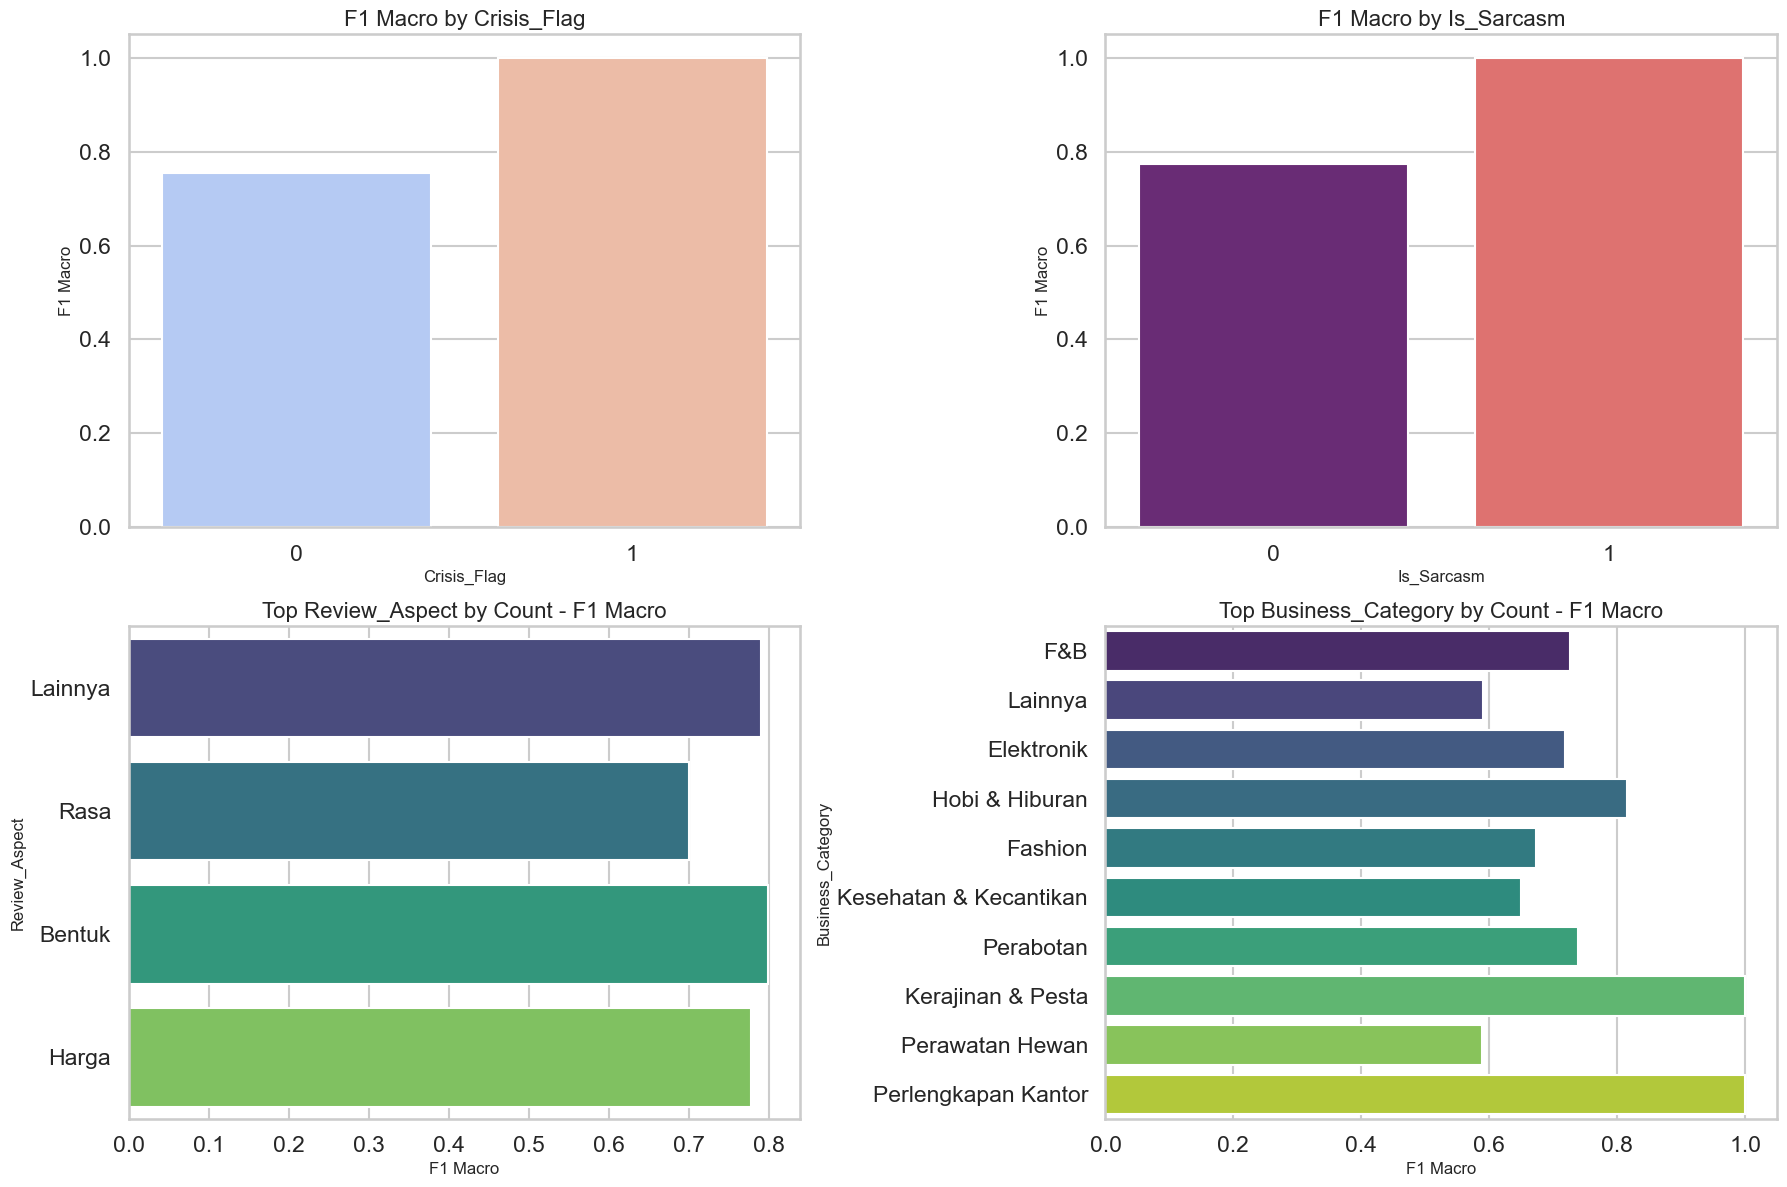

,Crisis_Flag,count,accuracy,precision_macro,recall_macro,f1_macro,group_type,Is_Sarcasm,Review_Aspect,Business_Category
0,1.0,247,1.000000,1.000000,1.000000,1.000000,Crisis_Flag,NaN,NaN,NaN
1,0.0,2925,0.756923,0.761890,0.751840,0.755391,Crisis_Flag,NaN,NaN,NaN
2,NaN,31,1.000000,1.000000,1.000000,1.000000,Is_Sarcasm,1.0,NaN,NaN
3,NaN,3141,0.773639,0.778138,0.773490,0.774733,Is_Sarcasm,0.0,NaN,NaN
4,NaN,718,0.817549,0.794679,0.803687,0.798595,Review_Aspect,NaN,Bentuk,NaN
5,NaN,1296,0.787809,0.794351,0.787470,0.789522,Review_Aspect,NaN,Lainnya,NaN
6,NaN,247,0.801619,0.814873,0.754988,0.776828,Review_Aspect,NaN,Harga,NaN
7,NaN,911,0.718990,0.713757,0.691778,0.700287,Review_Aspect,NaN,Rasa,NaN
8,NaN,11,1.000000,1.000000,1.000000,1.000000,Business_Category,NaN,NaN,Ibu & Bayi
9,NaN,16,1.000000,1.000000,1.000000,1.000000,Business_Category,NaN,NaN,Kerajinan & Pesta


In [279]:
def subgroup_metrics(df_source, actual_array, pred_array, group_col, min_count=1):
    temp = df_source[[group_col]].copy()
    temp['Actual'] = actual_array
    temp['Predicted'] = pred_array
    rows = []
    for group_value, group_df in temp.groupby(group_col):
        if len(group_df) < min_count:
            continue
        rows.append({
            group_col: group_value,
            'count': len(group_df),
            'accuracy': accuracy_score(group_df['Actual'], group_df['Predicted']),
            'precision_macro': precision_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'recall_macro': recall_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'f1_macro': f1_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
        })
    return pd.DataFrame(rows).sort_values('f1_macro', ascending=False)

crisis_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Crisis_Flag')
sarcasm_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Is_Sarcasm')
aspect_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Review_Aspect', min_count=10)
category_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Business_Category', min_count=10)

display(crisis_metrics)
display(sarcasm_metrics)
display(aspect_metrics)
display(category_metrics)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('F1 Macro by Crisis_Flag')
axes[0, 0].set_xlabel('Crisis_Flag')
axes[0, 0].set_ylabel('F1 Macro')

sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('F1 Macro by Is_Sarcasm')
axes[0, 1].set_xlabel('Is_Sarcasm')
axes[0, 1].set_ylabel('F1 Macro')

aspect_plot = aspect_metrics.sort_values('count', ascending=False).head(10)
sns.barplot(data=aspect_plot, y='Review_Aspect', x='f1_macro', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Top Review_Aspect by Count - F1 Macro')
axes[1, 0].set_xlabel('F1 Macro')
axes[1, 0].set_ylabel('Review_Aspect')

category_plot = category_metrics.sort_values('count', ascending=False).head(10)
sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top Business_Category by Count - F1 Macro')
axes[1, 1].set_xlabel('F1 Macro')
axes[1, 1].set_ylabel('Business_Category')

plt.tight_layout()
plt.show()

business_summary = pd.concat([
    crisis_metrics.assign(group_type='Crisis_Flag'),
    sarcasm_metrics.assign(group_type='Is_Sarcasm'),
    aspect_metrics.assign(group_type='Review_Aspect'),
    category_metrics.assign(group_type='Business_Category'),
], ignore_index=True)
display(business_summary)

## SECTION 14 - Model Comparison

Bagian ini membandingkan hasil Linear SVM dengan Logistic Regression.

Notebook akan mencoba mengimpor hasil Logistic Regression dari file hasil eksperimen sebelumnya.
Jika file belum tersedia, notebook akan menjalankan fallback Logistic Regression baseline agar perbandingan tetap dapat dibuat.

Logistic Regression metrics loaded from: results\model1\metrics_logistic_regression.csv


,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.773014,0.776767,0.773001,0.774043
1,test,0.775851,0.779867,0.775873,0.776829


,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.729823,0.729833,0.729787,0.729777
1,test,0.737705,0.737124,0.737732,0.737296


,Metric,Logistic Regression,Enhanced Linear SVM
0,Accuracy,0.737705,0.775851
1,Precision,0.737124,0.779867
2,Recall,0.737732,0.775873
3,F1,0.737296,0.776829


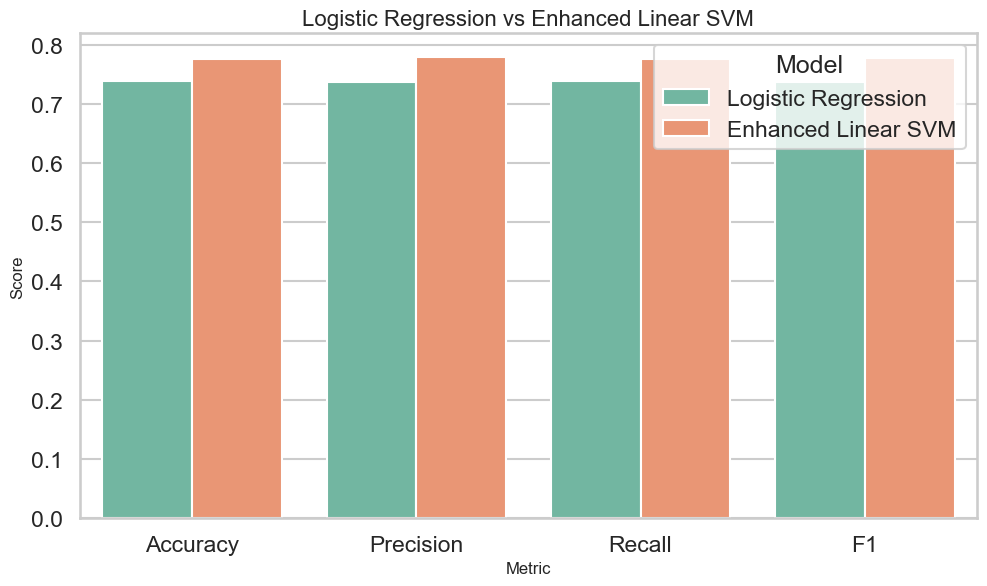

In [280]:
def summarize_metrics(split_name, y_true, y_pred):
    return {
        'split': split_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),
        'recall_macro': recall_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),
        'f1_macro': f1_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        ),
    }


lr_metrics_path_candidates = [
    Path("results/model1/metrics_logistic_regression.csv"),
    Path("metrics_logistic_regression.csv"),
]

lr_metrics_df = None

for candidate in lr_metrics_path_candidates:
    if candidate.exists():
        lr_metrics_df = pd.read_csv(candidate)
        print(f"Logistic Regression metrics loaded from: {candidate}")
        break

if lr_metrics_df is None:
    print("Logistic Regression metrics not found")


svm_comparison_metrics = pd.DataFrame([
    summarize_metrics(
        'validation',
        val_y,
        val_pred
    ),
    summarize_metrics(
        'test',
        test_y,
        test_pred
    ),
])

display(svm_comparison_metrics)

if lr_metrics_df is not None:

    display(lr_metrics_df)

    compare_table = pd.DataFrame({
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall',
            'F1'
        ],
        'Logistic Regression': [
            float(
                lr_metrics_df.loc[
                    lr_metrics_df['split'] == 'test',
                    'accuracy'
                ].iloc[0]
            ),
            float(
                lr_metrics_df.loc[
                    lr_metrics_df['split'] == 'test',
                    'precision_macro'
                ].iloc[0]
            ),
            float(
                lr_metrics_df.loc[
                    lr_metrics_df['split'] == 'test',
                    'recall_macro'
                ].iloc[0]
            ),
            float(
                lr_metrics_df.loc[
                    lr_metrics_df['split'] == 'test',
                    'f1_macro'
                ].iloc[0]
            ),
        ],
        'Enhanced Linear SVM': [
            float(
                svm_comparison_metrics.loc[
                    svm_comparison_metrics['split'] == 'test',
                    'accuracy'
                ].iloc[0]
            ),
            float(
                svm_comparison_metrics.loc[
                    svm_comparison_metrics['split'] == 'test',
                    'precision_macro'
                ].iloc[0]
            ),
            float(
                svm_comparison_metrics.loc[
                    svm_comparison_metrics['split'] == 'test',
                    'recall_macro'
                ].iloc[0]
            ),
            float(
                svm_comparison_metrics.loc[
                    svm_comparison_metrics['split'] == 'test',
                    'f1_macro'
                ].iloc[0]
            ),
        ],
    })

    display(compare_table)

    fig, ax = plt.subplots(figsize=(10, 6))

    compare_plot = compare_table.melt(
        id_vars='Metric',
        var_name='Model',
        value_name='Score'
    )

    sns.barplot(
        data=compare_plot,
        x='Metric',
        y='Score',
        hue='Model',
        ax=ax,
        palette='Set2'
    )

    ax.set_title(
        'Logistic Regression vs Enhanced Linear SVM'
    )
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')

    plt.tight_layout()
    plt.show()

else:

    print(
        "Skipping comparison because Logistic Regression metrics are unavailable."
    )

In [281]:
print(
    classification_report(
        test_y,
        test_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

    Negative     0.8452    0.7630    0.8020      1059
     Neutral     0.6952    0.7465    0.7199      1057
    Positive     0.7993    0.8182    0.8086      1056

    accuracy                         0.7759      3172
   macro avg     0.7799    0.7759    0.7768      3172
weighted avg     0.7799    0.7759    0.7768      3172



## SECTION 15 - Model Saving

Agar model dapat digunakan kembali tanpa retraining, notebook menyimpan tiga artefak utama:
- `svm_model.joblib`
- `tfidf_vectorizer.joblib`
- `label_encoder.joblib`

In [282]:
artifacts_dir = Path("artifacts/model2")
artifacts_dir.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    best_model,
    artifacts_dir / "svm_model.joblib"
)

joblib.dump(
    word_tfidf,
    artifacts_dir / "word_tfidf_vectorizer.joblib"
)

joblib.dump(
    char_tfidf,
    artifacts_dir / "char_tfidf_vectorizer.joblib"
)

joblib.dump(
    label_encoder,
    artifacts_dir / "label_encoder.joblib"
)

joblib.dump(
    ohe,
    artifacts_dir / "onehot_encoder.joblib"
)

print("=" * 60)
print("MODEL ARTIFACTS SAVED")
print("=" * 60)

for file in artifacts_dir.glob("*"):
    print(file.name)

print("\nSaved to:")
print(artifacts_dir.resolve())

MODEL ARTIFACTS SAVED
char_tfidf_vectorizer.joblib
label_encoder.joblib
onehot_encoder.joblib
svm_model.joblib
word_tfidf_vectorizer.joblib

Saved to:
C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\artifacts\model2


## SECTION 16 - Export Result

Section ini mengekspor hasil eksperimen agar dapat dipakai langsung untuk pelaporan capstone, audit model, dan dokumentasi advisor meeting.

File yang disimpan:
- `metrics_svm.csv`
- `predictions_svm.csv`
- `classification_report_svm.csv`

In [283]:
results_dir = Path("results/model2")
results_dir.mkdir(
    parents=True,
    exist_ok=True
)

metrics_export = pd.DataFrame([val_metrics, test_metrics])
metrics_export.to_csv(results_dir / 'metrics_svm.csv', index=False)

def decision_scores(model, x):
    scores = model.decision_function(x)
    if scores.ndim == 1:
        scores = scores[:, None]
    return scores

val_scores = decision_scores(
    final_classifier,
    X_val_final
)

test_scores = decision_scores(
    final_classifier,
    X_test_final
)

prediction_export = pd.concat([
    pd.DataFrame({
        'split': 'validation',
        'Review_Text_Processed': X_val.values,
        'Actual_Label': pd.Series(val_y).map(inverse_label_mapping).values,
        'Predicted_Label': pd.Series(val_pred).map(inverse_label_mapping).values,
        **{f'score_{cls}': val_scores[:, idx] for idx, cls in enumerate(class_names)},
    }),
    pd.DataFrame({
        'split': 'test',
        'Review_Text_Processed': X_test.values,
        'Actual_Label': pd.Series(test_y).map(inverse_label_mapping).values,
        'Predicted_Label': pd.Series(test_pred).map(inverse_label_mapping).values,
        **{f'score_{cls}': test_scores[:, idx] for idx, cls in enumerate(class_names)},
    }),
], ignore_index=True)
prediction_export.to_csv(results_dir / 'predictions_svm.csv', index=False)

def report_to_export_df(y_true, y_pred, split_name):
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={'index': 'label'})
    report_df['split'] = split_name
    return report_df[['split', 'label', 'precision', 'recall', 'f1-score', 'support']]

classification_report_export = pd.concat([
    report_to_export_df(val_y, val_pred, 'validation'),
    report_to_export_df(test_y, test_pred, 'test'),
], ignore_index=True)
classification_report_export.to_csv(results_dir / 'classification_report_svm.csv', index=False)

display(metrics_export)
display(prediction_export.head())
display(classification_report_export.head())
print('Exported files to:', results_dir.resolve())

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.773014,0.776767,0.773001,0.774043
1,test,0.775851,0.779867,0.775873,0.776829


,split,Review_Text_Processed,Actual_Label,Predicted_Label,score_Negative,score_Neutral,score_Positive
0,validation,packing rapi,Positive,Positive,-2.052328,-1.283774,0.967759
1,validation,pasti alat makan,Neutral,Positive,-1.560720,0.335853,0.492743
2,validation,tidak_sesuai dharapkan harap merek maspion nyata merek mikado label tempel maspion,Negative,Negative,6.957570,-6.974459,-3.670909
3,validation,bagus layan oke makan oke,Positive,Positive,-2.158834,-1.316408,1.601663
4,validation,the bar ambiance is good we ordered chilli broccoli and that had mix of broccoli and cauliflower broccoli was it is at the outer area so there was problem for booking cab also at pm while returning,Negative,Negative,3.454216,-3.620361,-2.255535


,split,label,precision,recall,f1-score,support
0,validation,Negative,0.831795,0.766541,0.797836,1058.000000
1,validation,Neutral,0.694323,0.752841,0.722399,1056.000000
2,validation,Positive,0.804183,0.799622,0.801896,1058.000000
3,validation,accuracy,0.773014,0.773014,0.773014,0.773014
4,validation,macro avg,0.776767,0.773001,0.774043,3172.000000


Exported files to: C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\results\model2


## SECTION 17 - Final Conclusion

Ringkasan otomatis berikut dihasilkan dari metrik validation dan test. Bagian ini dapat langsung dipakai sebagai bahan narasi laporan capstone atau diskusi advisor meeting.

In [284]:
summary_df = pd.DataFrame({
    "Model": ["Linear SVM"],
    "Validation_F1": [val_metrics["f1_macro"]],
    "Test_F1": [test_metrics["f1_macro"]],
    "TFIDF": ["(1,3) | max_features=50000"]
})
display(summary_df)

,Model,Validation_F1,Test_F1,TFIDF
0,Linear SVM,0.774043,0.776829,"(1,3) | max_features=50000"


In [285]:
final_conclusion_md = f'''
### Final Conclusion

**Final Test Performance**
- Accuracy: {test_metrics['accuracy']:.4f}
- Precision: {test_metrics['precision_macro']:.4f}
- Recall: {test_metrics['recall_macro']:.4f}
- F1 Score: {test_metrics['f1_macro']:.4f}

**Strength**
- Linear SVM sangat cocok untuk feature sparse seperti TF-IDF.
- Model ini memiliki decision boundary yang tegas dan sering unggul pada klasifikasi teks.
- Koefisien model dapat digunakan untuk interpretasi feature importance.

**Weakness**
- Model linear tetap terbatas dalam menangkap konteks yang sangat kompleks, sarcasm, dan negasi panjang.
- Performa tetap sensitif terhadap kualitas feature engineering dan preprocessing.
- Interpretasi koefisien masih bersifat linear dan tidak menangkap interaksi konteks yang lebih kaya.

**Apakah layak menjadi model final**
- Jika hasil test menunjukkan F1 Macro yang lebih baik dibanding Logistic Regression, model ini layak dijadikan kandidat model final baseline.
- Jika gap performanya kecil, Linear SVM tetap layak dipilih karena interpretabilitas dan stabilitasnya pada text classification.
- Jika kebutuhan bisnis menuntut konteks yang lebih dalam, model ini sebaiknya menjadi baseline kuat sebelum mencoba transformer.
'''

display(Markdown(final_conclusion_md))


### Final Conclusion

**Final Test Performance**
- Accuracy: 0.7759
- Precision: 0.7799
- Recall: 0.7759
- F1 Score: 0.7768

**Strength**
- Linear SVM sangat cocok untuk feature sparse seperti TF-IDF.
- Model ini memiliki decision boundary yang tegas dan sering unggul pada klasifikasi teks.
- Koefisien model dapat digunakan untuk interpretasi feature importance.

**Weakness**
- Model linear tetap terbatas dalam menangkap konteks yang sangat kompleks, sarcasm, dan negasi panjang.
- Performa tetap sensitif terhadap kualitas feature engineering dan preprocessing.
- Interpretasi koefisien masih bersifat linear dan tidak menangkap interaksi konteks yang lebih kaya.

**Apakah layak menjadi model final**
- Jika hasil test menunjukkan F1 Macro yang lebih baik dibanding Logistic Regression, model ini layak dijadikan kandidat model final baseline.
- Jika gap performanya kecil, Linear SVM tetap layak dipilih karena interpretabilitas dan stabilitasnya pada text classification.
- Jika kebutuhan bisnis menuntut konteks yang lebih dalam, model ini sebaiknya menjadi baseline kuat sebelum mencoba transformer.
